In [168]:
import sklearn as sc
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [169]:
df_mat = pd.read_csv("ML/4/student-mat.csv", sep=";")
df_por = pd.read_csv("ML/4/student-por.csv", sep=";")     #Apres avoir lu la doc, avant de commencer l'analyse exploratoire je merge mes dfs avec les variables conseillé par les auteurs du sujet nous pourrons voir la suite si les matieres deviennent des features pertinentes. 

df = pd.merge(df_mat, df_por, on=["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob","reason","nursery","internet"])

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [170]:
df.shape  #Nous avons donc maintenant 382 élèves.

(382, 53)

In [171]:
df.isnull().sum() #0 valeurs nuls

school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            0
Fedu            0
Mjob            0
Fjob            0
reason          0
guardian_x      0
traveltime_x    0
studytime_x     0
failures_x      0
schoolsup_x     0
famsup_x        0
paid_x          0
activities_x    0
nursery         0
higher_x        0
internet        0
romantic_x      0
famrel_x        0
freetime_x      0
goout_x         0
Dalc_x          0
Walc_x          0
health_x        0
absences_x      0
G1_x            0
G2_x            0
G3_x            0
guardian_y      0
traveltime_y    0
studytime_y     0
failures_y      0
schoolsup_y     0
famsup_y        0
paid_y          0
activities_y    0
higher_y        0
romantic_y      0
famrel_y        0
freetime_y      0
goout_y         0
Dalc_y          0
Walc_y          0
health_y        0
absences_y      0
G1_y            0
G2_y            0
G3_y            0
dtype: int64

In [172]:
df.duplicated().sum() # Je compte ensuite le nombre de doublons

np.int64(0)

In [173]:
print("Colonnes numériques :")
print(df.select_dtypes(include="number").columns.tolist())

print("\nColonnes catégorielles :")
print(df.select_dtypes(include="object").columns.tolist())   #Je dinstigue ici quelle variables sont numeriques ou categorielles pour soit les transformer binaires ou les encoder.

print(f"Numériques : {df.select_dtypes(include='number').shape[1]}")
print(f"Catégorielles : {df.select_dtypes(include='object').shape[1]}")


Colonnes numériques :
['age', 'Medu', 'Fedu', 'traveltime_x', 'studytime_x', 'failures_x', 'famrel_x', 'freetime_x', 'goout_x', 'Dalc_x', 'Walc_x', 'health_x', 'absences_x', 'G1_x', 'G2_x', 'G3_x', 'traveltime_y', 'studytime_y', 'failures_y', 'famrel_y', 'freetime_y', 'goout_y', 'Dalc_y', 'Walc_y', 'health_y', 'absences_y', 'G1_y', 'G2_y', 'G3_y']

Colonnes catégorielles :
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian_x', 'schoolsup_x', 'famsup_x', 'paid_x', 'activities_x', 'nursery', 'higher_x', 'internet', 'romantic_x', 'guardian_y', 'schoolsup_y', 'famsup_y', 'paid_y', 'activities_y', 'higher_y', 'romantic_y']
Numériques : 29
Catégorielles : 24


/tmp/ipykernel_10029/2627637661.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())   #Je dinstigue ici quelle variables sont numeriques ou categorielles pour soit les transformer binaires ou les encoder.
/tmp/ipykernel_10029/2627637661.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and s

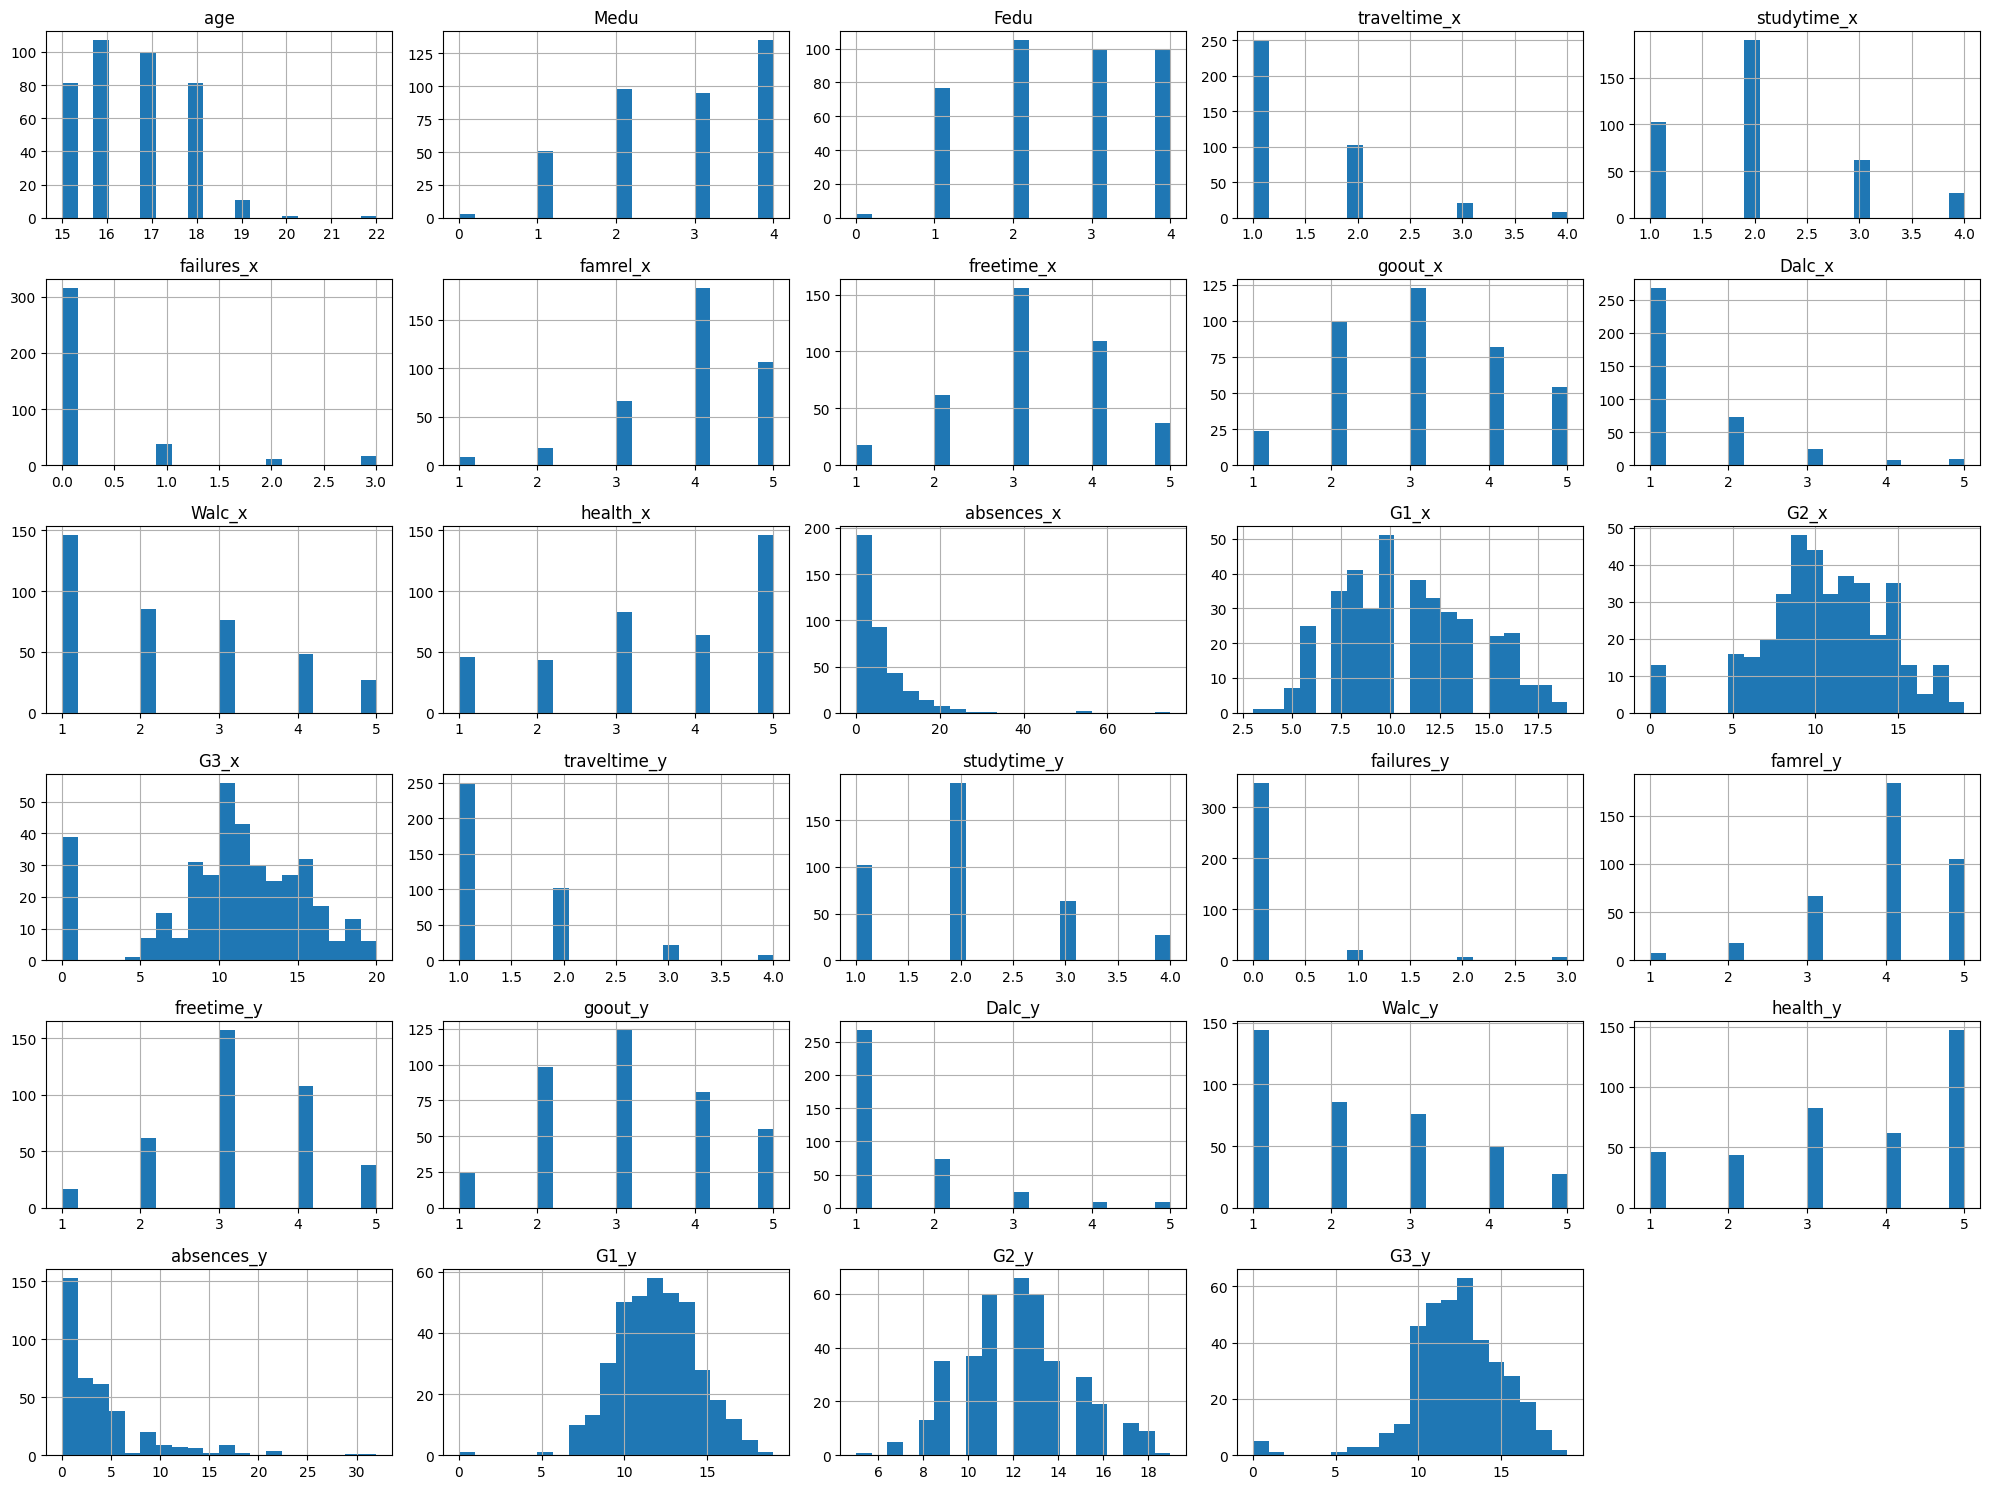

In [174]:

df.select_dtypes(include="number").hist(figsize=(20, 15), bins=20)
plt.tight_layout()   #on voit que les donneées sont clairement asymetriques donc nous partirons sur l'iqr pour les outliers
plt.show()


In [175]:
Q1 = df.select_dtypes(include='number').quantile(0.25)
Q3 = df.select_dtypes(include='number').quantile(0.75)

IQR = Q3-Q1    #On voit que les variables absences_x et absences_y présentent des outliers significatifs (IQR de 8 et 6). Les failures ont un IQR de 0 (majorité à 0), la méthode IQR n'est pas applicable dessus. On visualise en boxplot avant de winsoriser les absences.

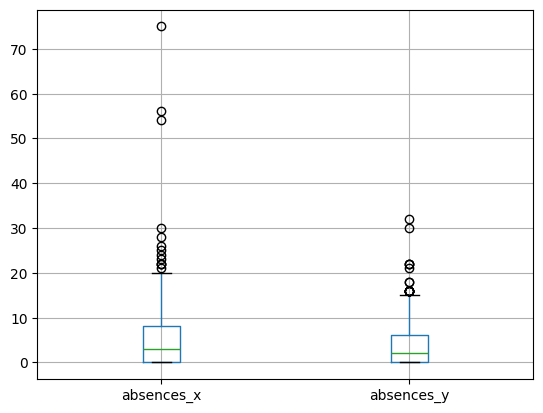

In [176]:
df[["absences_x", "absences_y"]].boxplot()
plt.show()

In [177]:
for col in ["absences_x", "absences_y"]:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df[col] = df[col].clip(lower, upper)

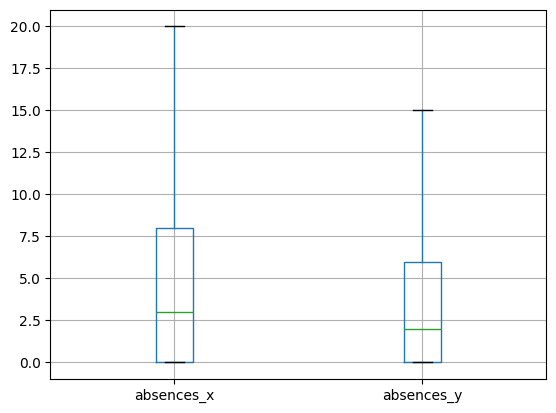

In [178]:
df[["absences_x", "absences_y"]].boxplot()
plt.show()   #Parfait, passons l'encodage

In [179]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols_bin = ["school", "sex", "address", "famsize", "Pstatus", 
            "schoolsup_x", "schoolsup_y", "famsup_x", "famsup_y", 
            "paid_x", "paid_y", "activities_x", "activities_y", 
            "nursery", "higher_x", "higher_y", "internet", 
            "romantic_x", "romantic_y"]


for col in cols_bin:
    df[col] = le.fit_transform(df[col])

df[cols_bin].head()


,school,sex,address,famsize,Pstatus,schoolsup_x,schoolsup_y,famsup_x,famsup_y,paid_x,paid_y,activities_x,activities_y,nursery,higher_x,higher_y,internet,romantic_x,romantic_y
0,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,1,0,0,0
1,0,0,1,0,1,0,0,1,1,0,0,0,0,0,1,1,1,0,0
2,0,0,1,1,1,1,1,0,0,1,0,0,0,1,1,1,1,0,0
3,0,0,1,0,1,0,0,1,1,1,0,1,1,1,1,1,1,1,1
4,0,0,1,0,1,0,0,1,1,1,0,0,0,1,1,1,0,0,0


In [180]:
# Encodage des variables nominales (plus de 2 catégories)
encoder = OneHotEncoder(sparse_output=False, drop="first")

colonnes_nominales = ["Mjob", "Fjob", "reason", "guardian_x", "guardian_y"]

for colonne in colonnes_nominales:
    col_nom = encoder.fit_transform(df[[colonne]])
    noms = encoder.get_feature_names_out([colonne])
    df[noms] = col_nom
    df = df.drop(colonne, axis=1)

    
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime_x,studytime_x,...,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_x_mother,guardian_x_other,guardian_y_mother,guardian_y_other
0,0,0,18,1,0,0,4,4,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0,0,17,1,0,1,1,1,1,2,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,15,1,1,1,1,1,1,2,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,0,0,15,1,0,1,4,2,1,3,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0,0,16,1,0,1,3,3,1,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


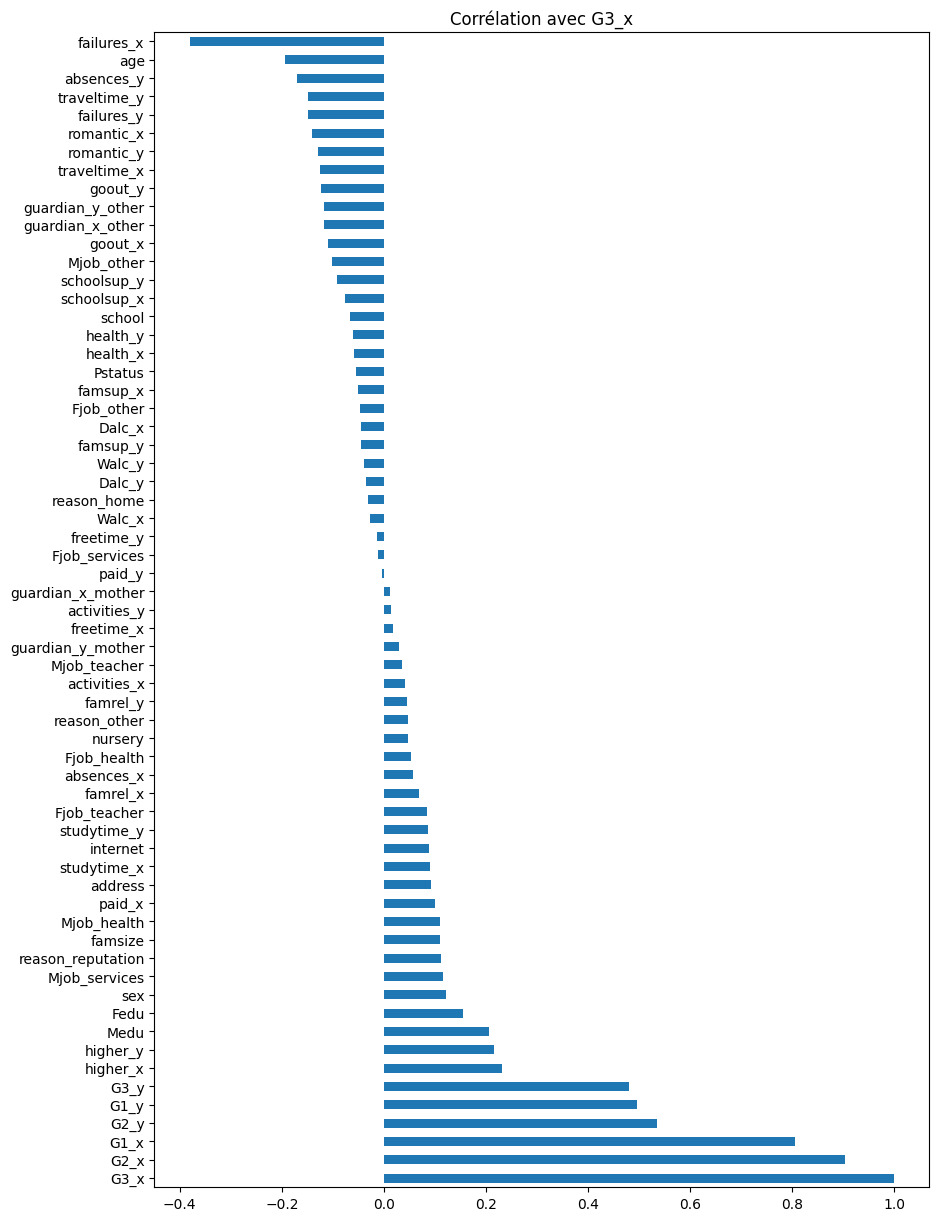

In [181]:
df.corr()["G3_x"].sort_values(ascending=False).plot(kind="barh", figsize=(10, 15))
plt.title("Corrélation avec G3_x")
plt.show()

#Grace a la visualisation de notre correlation on peut voir les G2 et G1 sont trop correlet ont les drop et on les remplace pas une moyenne general des trois années.

In [182]:
df["moyenne_por"] = (df["G1_y"] + df["G2_y"] + df["G3_y"]) / 3

In [183]:
from sklearn.model_selection import train_test_split

y = df["G3_x"] #Mon objectif de prediction
X = df.drop(["G3_x", "G1_x", "G2_x"], axis=1)    #Je split nos données en 70 30 car pas beaucoup de données

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [184]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# A. Régression linéaire
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# B. Arbre de décision (pas de scaler)
pipe_dt = Pipeline([
    ("model", DecisionTreeRegressor(random_state=42))
])

# C. Réseau de neurones
pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(random_state=42, max_iter=1000))])


In [185]:
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_mlp.fit(X_train, y_train)

pred_lr = pipe_lr.predict(X_test)
pred_dt = pipe_dt.predict(X_test)
pred_mlp = pipe_mlp.predict(X_test)

In [187]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#On calcule les metriques pour chaque modele
print(' Regression lineaire ')
print('MAE:', round(mean_absolute_error(y_test, pred_lr), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_lr)), 2))
print('R²:', round(r2_score(y_test, pred_lr), 2))

print('Arbre de decision')
print('MAE:', round(mean_absolute_error(y_test, pred_dt), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_dt)), 2))
print('R²:', round(r2_score(y_test, pred_dt), 2))

print(' MLP ')
print('MAE:', round(mean_absolute_error(y_test, pred_mlp), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, pred_mlp)), 2))
print('R²:', round(r2_score(y_test, pred_mlp), 2))


#La regression lineaire est clairement la meilleure avec un R² de 0.35 et la MAE la plus basse (2.71). L'arbre de decision est mauvais avec un R² negatif ca veut dire qu'il fait pire qu'une simple moyenne. Le MLP est pas ouf non plus avec un R² de 0.05

 Regression lineaire 
MAE: 2.71
RMSE: 3.54
R²: 0.35
Arbre de decision
MAE: 3.26
RMSE: 4.47
R²: -0.03
 MLP 
MAE: 3.13
RMSE: 4.28
R²: 0.05


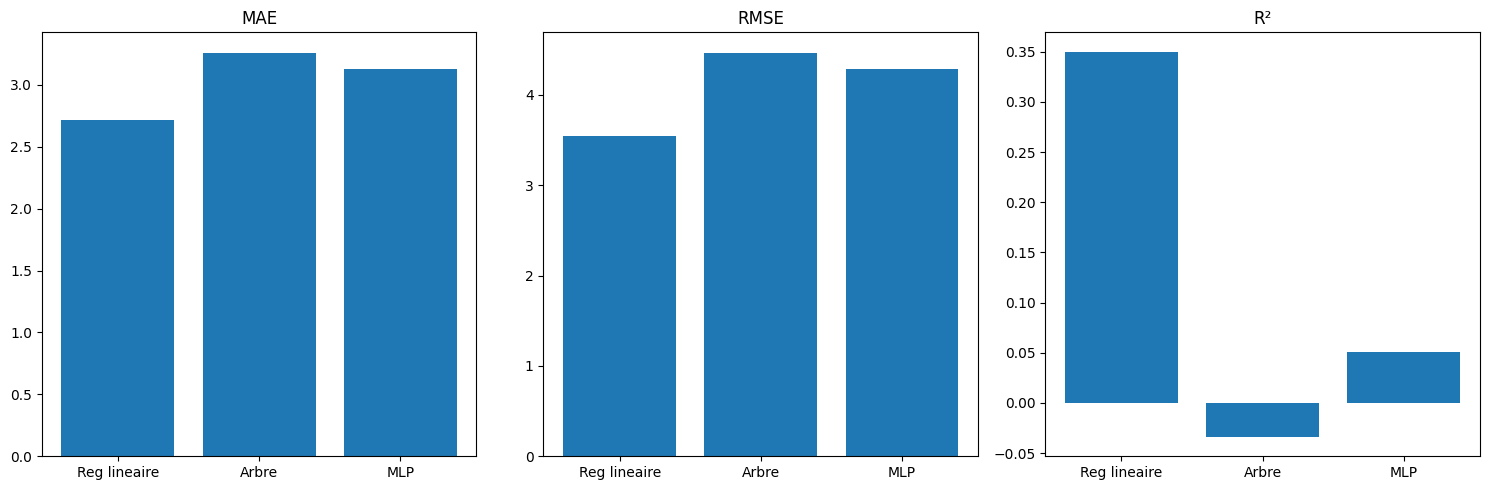

In [188]:
#Visualisation pour comparer les scores
mae_lr = mean_absolute_error(y_test, pred_lr)
mae_dt = mean_absolute_error(y_test, pred_dt)
mae_mlp = mean_absolute_error(y_test, pred_mlp)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_dt = np.sqrt(mean_squared_error(y_test, pred_dt))
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))

r2_lr = r2_score(y_test, pred_lr)
r2_dt = r2_score(y_test, pred_dt)
r2_mlp = r2_score(y_test, pred_mlp)

noms = ['Reg lineaire', 'Arbre', 'MLP']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].bar(noms, [mae_lr, mae_dt, mae_mlp])
axes[0].set_title('MAE')
axes[1].bar(noms, [rmse_lr, rmse_dt, rmse_mlp])
axes[1].set_title('RMSE')
axes[2].bar(noms, [r2_lr, r2_dt, r2_mlp])
axes[2].set_title('R²')
plt.tight_layout()
plt.show()

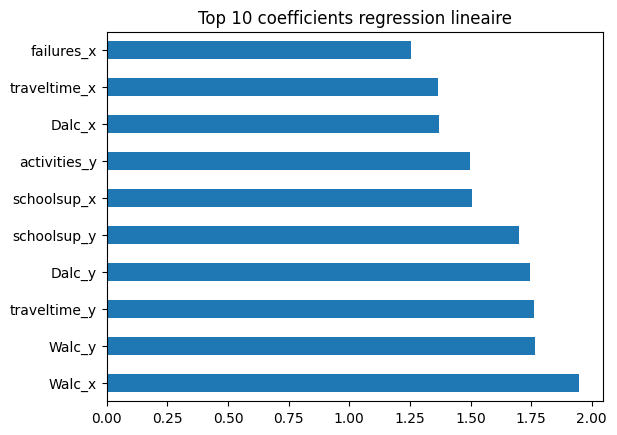

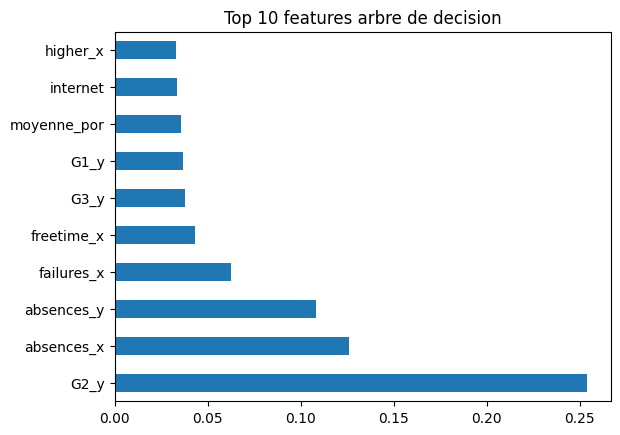

In [189]:
#On regarde quelles variables comptent le plus pour la regression lineaire
coefs = pd.Series(pipe_lr.named_steps['model'].coef_, index=X.columns)
top10_coefs = coefs.abs().sort_values(ascending=False).head(10)
top10_coefs.plot(kind='barh')
plt.title('Top 10 coefficients regression lineaire')
plt.show()

#Pareil pour l'arbre de decision
feat_imp = pd.Series(pipe_dt.named_steps['model'].feature_importances_, index=X.columns)
top10_feat = feat_imp.sort_values(ascending=False).head(10)
top10_feat.plot(kind='barh')
plt.title('Top 10 features arbre de decision')
plt.show()

In [190]:
#Test de robustesse on change le random_state pour voir si les scores bougent beaucoup
print('Robustesse arbre de decision :')
for rs in [0, 21, 42, 77, 99]:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=rs)
    arbre_test = DecisionTreeRegressor(random_state=42)
    arbre_test.fit(X_tr, y_tr)
    pred = arbre_test.predict(X_te)
    print('random_state', rs, ': R²:', round(r2_score(y_te, pred), 2))


#On voit que les scores de l'arbre bougent beaucoup selon le random_state (de 0.17 a -0.17) donc le modele n'est pas du tout robuste. Il est tres sensible a comment on coupe les données

Robustesse arbre de decision :
random_state 0 -> R²: 0.17
random_state 21 -> R²: 0.14
random_state 42 -> R²: -0.03
random_state 77 -> R²: -0.17
random_state 99 -> R²: -0.1


In [191]:
#On test differentes profondeurs pour voir si l'arbre surapprend
print('Test profondeur arbre :')
for depth in [2, 4, 6, 8, 10, None]:
    arbre = DecisionTreeRegressor(max_depth=depth, random_state=42)
    arbre.fit(X_train, y_train)
    score_train = round(r2_score(y_train, arbre.predict(X_train)), 2)
    score_test = round(r2_score(y_test, arbre.predict(X_test)), 2)
    print('profondeur', depth, ': Train R²:', score_train, '| Test R²:', score_test)


#On voit clairement le surapprentissage : a profondeur 2 le Train R² est 0.38 et Test 0.24 c'est correct, mais a profondeur None le Train monte a 1.0 et le Test descend a -0.03. L'arbre apprend par coeur les données d'entrainement mais generalise tres mal. La meilleure profondeur serait 2 ou 4

Test profondeur arbre :
profondeur 2 -> Train R²: 0.38 | Test R²: 0.24
profondeur 4 -> Train R²: 0.62 | Test R²: 0.25
profondeur 6 -> Train R²: 0.82 | Test R²: 0.13
profondeur 8 -> Train R²: 0.95 | Test R²: -0.11
profondeur 10 -> Train R²: 0.99 | Test R²: -0.11
profondeur None -> Train R²: 1.0 | Test R²: -0.03


In [192]:
#On test differentes tailles de couches cachées pour le MLP
print('Tuning MLP :')
for hidden in [(50,), (100,), (50, 50), (100, 50)]:
    mlp = MLPRegressor(hidden_layer_sizes=hidden, random_state=42, max_iter=1000)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train)
    X_te_scaled = scaler.transform(X_test)
    mlp.fit(X_tr_scaled, y_train)
    pred = mlp.predict(X_te_scaled)
    print('hidden', hidden, ': R²:', round(r2_score(y_test, pred), 2), '| MAE:', round(mean_absolute_error(y_test, pred), 2))


#Le MLP avec hidden (100, 50) donne le meilleur R² (0.09) mais ca reste faible. Le warning de convergence veut dire que le modele n'a pas fini d'apprendre en 1000 iterations. On pourrait augmenter max_iter mais les resultats restent pas terribles

Tuning MLP :


/home/alexis/Lab/envml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


hidden (50,) -> R²: -0.08 | MAE: 3.4
hidden (100,) -> R²: 0.05 | MAE: 3.13
hidden (50, 50) -> R²: 0.05 | MAE: 3.33
hidden (100, 50) -> R²: 0.09 | MAE: 3.14


La régression linéaire est clairement le meilleur choix ici.

C’est le seul modèle qui reste cohérent : meilleur R² (0.35), meilleure MAE (2.71) et RMSE (3.54). Les performances ne sont pas énormes, mais au moins elles sont stables.

À l’inverse, l’arbre de décision surapprend complètement (R² train = 1.0 vs test = -0.03), donc il ne généralise pas du tout. Le MLP ne fait pas beaucoup mieux, même en testant plusieurs configurations (R² max ≈ 0.09).

Enfin, les variables les plus importantes viennent des notes de portugais (moyenne_por, G2_y), ce qui confirme que le merge était pertinent : les performances dans une matière aident à prédire celles dans une autre.